# Notebook 1 — Data Preparation

## Step 1: Eligible Participant Dataset

### 1.1 Attention Check Logic

In [1]:
import pandas as pd
import numpy as np

participants = pd.read_csv('../data/participants.csv')
cr = pd.read_csv('../data/confidence_risk.csv')

# Correct answers per experiment key
attn_correct = {
    'e1': {3: 2, 7: 4},
    'e6': {3: 2, 7: 4},
    'e2': {3: 2, 7: 5},
    'e3': {3: 2, 7: 5},
    'e4': {3: 2, 7: 5},
    'e5': {3: 2, 7: 5},
}

# Merge experiment_key into confidence_risk
cr = cr.merge(participants[['participant_id', 'experiment_key']], on='participant_id', how='left')

# Isolate attention check rows
attn = cr[cr['attention_check_response'].notna()].copy()

def check_pass(row):
    correct = attn_correct.get(row['experiment_key'], {}).get(int(row['completed_after_task']), None)
    if correct is None:
        return None  # unexpected placement — flag for review
    return int(row['attention_check_response']) == correct

attn['passed'] = attn.apply(check_pass, axis=1)

# Cast to int before pivot to guarantee integer column labels regardless of CSV dtype
attn['completed_after_task'] = attn['completed_after_task'].astype(int)

# Pivot to one row per participant: pass_task3, pass_task7
attn_pivot = attn.pivot_table(
    index='participant_id',
    columns='completed_after_task',
    values='passed',
    aggfunc='first'
).rename(columns={3: 'pass_task3', 7: 'pass_task7'})

# Exclusion rule: exclude only if BOTH failed
attn_pivot['failed_both'] = (attn_pivot['pass_task3'] == False) & (attn_pivot['pass_task7'] == False)

### 1.2 Apply Eligibility Criteria

All three criteria must be met:
1. `completed == True`
2. `withdrawn == False`
3. Failed both attention checks

In [2]:
eligible = (
    participants
    .merge(attn_pivot[['failed_both']], on='participant_id', how='left')
)
eligible['failed_both'] = eligible['failed_both'].fillna(False).astype(bool)  # astype(bool) required: object dtype after left merge makes ~ return -2/-1 (truthy), not False

eligible = eligible[
    (eligible['completed'] == True) &
    (eligible['withdrawn'] == False) &
    (~eligible['failed_both'])
].copy()

print(f'Eligible N: {len(eligible)}')  # expect 223

Eligible N: 223


### 1.3 Condition Assignment

Use `experiment_key` exclusively — do not use `show_profit_loss` or `show_information` from `task_responses.csv`.

In [3]:
info_map = {
    'e1': 'fixed_cost',
    'e2': 'dynamic_cost',
    'e3': 'none',
    'e4': 'fixed_cost',
    'e5': 'dynamic_cost',
    'e6': 'none',
}
pl_map = {
    'e1': True, 'e2': True, 'e3': True,
    'e4': False, 'e5': False, 'e6': False,
}

eligible['info_type'] = eligible['experiment_key'].map(info_map)
eligible['show_pl']   = eligible['experiment_key'].map(pl_map)

eligible_df = eligible[['participant_id', 'experiment_key', 'info_type', 'show_pl']].copy()

### 1.4 Differential Attrition Check

Verify that attention check failures are not concentrated in any single condition. p < 0.10 → run strict-exclusion sensitivity analysis.

In [4]:
from scipy.stats import chi2_contingency

fail_check = (
    participants
    .merge(attn_pivot[['failed_both']], on='participant_id', how='left')
    .assign(failed_both=lambda d: d['failed_both'].fillna(False))
    .groupby(['experiment_key', 'failed_both'])
    .size().unstack(fill_value=0)
    .rename(columns={False: 'passed_at_least_one', True: 'failed_both'})
)
print(fail_check)

ct_attn = pd.crosstab(
    participants.merge(attn_pivot[['failed_both']], on='participant_id', how='left')
               .assign(failed_both=lambda d: d['failed_both'].fillna(False))['experiment_key'],
    participants.merge(attn_pivot[['failed_both']], on='participant_id', how='left')
               .assign(failed_both=lambda d: d['failed_both'].fillna(False))['failed_both']
)
chi2_attn, p_attn, _, _ = chi2_contingency(ct_attn)
print(f'Chi-square (condition × failed_both): χ²={chi2_attn:.3f}, p={p_attn:.3f}')
if p_attn < 0.10:
    print('WARNING: p < 0.10 — failures are non-randomly distributed → run strict-exclusion sensitivity analysis in notebook 02 §12.')

failed_both     passed_at_least_one  failed_both
experiment_key                                  
e1                               59            0
e2                               44            3
e3                               41            2
e4                               47            1
e5                               46            1
e6                               48            0
Chi-square (condition × failed_both): χ²=6.788, p=0.237


**Differential attrition result:** χ²(5) = 6.788, *p* = .237. Failures are distributed across conditions (e2: 3, e3: 2, e4: 1, e5: 1; e1, e6: 0) and are not significantly concentrated in any single condition. No strict-exclusion sensitivity analysis is required; the liberal criterion (exclude only if both checks failed) is retained for all primary analyses.

### 1.5 Demographic Recoding and Participant Profile Table

**Verify column names against `data/demographics.csv` at runtime** — the mapping assumes a standard Qualtrics export.

In [5]:
demographics = pd.read_csv('../data/demographics.csv')
print('Demographics columns:', demographics.columns.tolist())  # verify at runtime

# Ordered category encodings — values match actual shorthand codes in demographics.csv
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
edu_order  = ['less-than-high-school', 'high-school', 'some-college', 'associate',
              'bachelors', 'masters', 'doctoral']
inc_order  = ['less-than-20k', '20k-39k', '40k-59k', '60k-79k',
              '80k-99k', '100k-149k', '150k-plus']
exp_order  = ['none', 'limited', 'some', 'moderate', 'extensive']

demographics['age_num']    = pd.Series(pd.Categorical(demographics['age_range'],  categories=age_order, ordered=True).codes).replace(-1, np.nan)
demographics['edu_num']    = pd.Series(pd.Categorical(demographics['education'],  categories=edu_order, ordered=True).codes).replace(-1, np.nan)
demographics['income_num'] = pd.Series(pd.Categorical(demographics['income'],     categories=inc_order, ordered=True).codes).replace(-1, np.nan)
demographics['exp_num']    = pd.Series(pd.Categorical(demographics['experience'], categories=exp_order, ordered=True).codes).replace(-1, np.nan)

# Binary compliance flags — actual column names in demographics.csv differ from plan shorthand
flag_renames = {'executive_shareholder': 'is_senior_exec', 'exchange_brokerage': 'works_for_brokerage'}
for raw_col, canonical in flag_renames.items():
    if raw_col in demographics.columns:
        demographics[f'{canonical}_bin'] = (demographics[raw_col] == 'yes').astype(int)
    else:
        print(f'WARNING: {raw_col} not found in demographics.csv — check column name.')

DEMO_COLS_BASE = ['participant_id', 'age_range', 'gender', 'education',
                  'employment', 'income', 'experience',
                  'age_num', 'edu_num', 'income_num', 'exp_num']
DEMO_COLS_OPT  = ['race', 'hispanic_latino', 'is_senior_exec_bin', 'works_for_brokerage_bin']
demo_cols_available = DEMO_COLS_BASE + [c for c in DEMO_COLS_OPT if c in demographics.columns]

eligible_df_demo = eligible_df.merge(
    demographics[[c for c in demo_cols_available if c in demographics.columns]],
    on='participant_id', how='left'
)
print(f'Demographics available for: {eligible_df_demo["age_range"].notna().sum()} / {len(eligible_df_demo)} participants')

Demographics columns: ['id', 'participant_id', 'age_range', 'gender', 'gender_self_describe', 'hispanic_latino', 'race', 'race_other', 'education', 'employment', 'executive_shareholder', 'exchange_brokerage', 'income', 'experience', 'submitted_at']
Demographics available for: 223 / 223 participants


#### Participant Characteristics Table (Table 1)

In [6]:
def freq_pct(df, col):
    vc = df[col].value_counts(dropna=False)
    return pd.DataFrame({'n': vc, '%': (vc / len(df) * 100).round(1)})

PROFILE_COLS = ['age_range', 'gender', 'education', 'employment', 'income', 'experience']
print('=== Participant Characteristics (Overall) ===')
for col in PROFILE_COLS:
    if col in eligible_df_demo.columns:
        print(f'\n{col}:')
        print(freq_pct(eligible_df_demo, col).to_string())

for col in ['hispanic_latino', 'race']:
    if col in eligible_df_demo.columns:
        print(f'\n{col} (descriptive only — not used in models):')
        print(freq_pct(eligible_df_demo, col).to_string())

for col in ['is_senior_exec', 'works_for_brokerage']:
    if col in eligible_df_demo.columns:
        print(f'\n{col}:')
        print(freq_pct(eligible_df_demo, col).to_string())

print('\n=== Characteristics by Condition (N per cell) ===')
for col in PROFILE_COLS:
    if col in eligible_df_demo.columns:
        ct = pd.crosstab(eligible_df_demo[col],
                         [eligible_df_demo['info_type'], eligible_df_demo['show_pl']])
        print(f'\n{col} × condition:')
        print(ct.to_string())

=== Participant Characteristics (Overall) ===

age_range:
            n     %
age_range          
35-44      66  29.6
25-34      58  26.0
45-54      36  16.1
55-64      25  11.2
65+        21   9.4
18-24      17   7.6

gender:
                     n     %
gender                      
male               113  50.7
female             109  48.9
prefer-not-to-say    1   0.4

education:
               n     %
education             
bachelors     88  39.5
some-college  36  16.1
high-school   31  13.9
masters       30  13.5
associate     30  13.5
doctoral       8   3.6

employment:
              n     %
employment           
employed    173  77.6
unemployed   25  11.2
retired      18   8.1
student       7   3.1

income:
                n     %
income                 
40k-59k        51  22.9
20k-39k        41  18.4
60k-79k        37  16.6
less-than-20k  35  15.7
80k-99k        25  11.2
100k-149k      22   9.9
150k-plus      12   5.4

experience:
             n     %
experience          
limited

### Sample Description

The final analytic sample consists of **N = 223** eligible participants (completed, not withdrawn, passed ≥1 attention check). The sample skews toward middle age (35–44: 30%, 25–34: 26%), is nearly evenly split by gender (51% male, 49% female), and is predominantly White (73%). Most participants hold at least a bachelor’s degree (57%) and are employed (78%). Income is concentrated in the lower-to-middle range (< $80k: 73%). Investing experience is broadly distributed: no experience 17%, limited 24%, some 22%, moderate 19%, extensive 18%.


### 1.6 Randomization / Balance Checks

Data-quality checks only — not substantive findings. Variables flagged as imbalanced (p < 0.05) should be added as covariates in robustness models in notebook 02 §12.

In [7]:
print('=== Randomization / Balance Checks ===')
BALANCE_VARS = ['age_range', 'gender', 'education', 'income', 'employment', 'experience']
balance_results = []

for col in BALANCE_VARS:
    if col not in eligible_df_demo.columns:
        print(f'{col}: column not found — skip.')
        continue
    ct = pd.crosstab(eligible_df_demo[col], eligible_df_demo['experiment_key'])
    ct = ct.loc[ct.sum(axis=1) > 0]
    if ct.shape[0] < 2:
        print(f'{col}: insufficient variation — skip.')
        continue
    chi2_bal, p_bal, dof_bal, _ = chi2_contingency(ct)
    n_bal = ct.values.sum()
    cramers_v = np.sqrt(chi2_bal / (n_bal * (min(ct.shape) - 1)))
    flag = '*** IMBALANCED' if p_bal < 0.05 else 'OK'
    print(f'{col:<22}: χ²({dof_bal}) = {chi2_bal:.3f}, p = {p_bal:.3f}, V = {cramers_v:.3f}  {flag}')
    balance_results.append({'variable': col, 'chi2': round(chi2_bal, 3), 'df': dof_bal,
                             'p': round(p_bal, 3), 'cramers_v': round(cramers_v, 3)})

df_balance = pd.DataFrame(balance_results)
imbalanced = df_balance[df_balance['p'] < 0.05]
if len(imbalanced) > 0:
    print('\nIMBALANCED variables — add as covariates in notebook 02 §12 robustness models:')
    print(imbalanced[['variable', 'chi2', 'p']].to_string(index=False))
else:
    print('\nAll checked variables balanced (p ≥ 0.05).')

=== Randomization / Balance Checks ===
age_range             : χ²(25) = 19.610, p = 0.767, V = 0.133  OK
gender                : χ²(10) = 5.440, p = 0.860, V = 0.110  OK
education             : χ²(25) = 29.112, p = 0.259, V = 0.162  OK
income                : χ²(30) = 22.535, p = 0.834, V = 0.142  OK
employment            : χ²(15) = 17.801, p = 0.273, V = 0.163  OK
experience            : χ²(20) = 27.435, p = 0.123, V = 0.175  OK

All checked variables balanced (p ≥ 0.05).


**Randomization result:** All six demographic variables are balanced across the six experimental conditions (all χ² *p* ≥ .12; Cramér’s *V* ≤ .18). No demographic covariate needs to be added to primary models on the basis of randomization failure. Per-condition Ns range from 35 to 39.

## Step 2: Event-Derived Per-Task Variables

Source: `events_cleaned.csv`. Restrict to **real tasks only**: `task_id` is not null AND `stock_ticker` does not start with `'TUT'`.

In [8]:
import json

events = pd.read_csv('../data/events_cleaned.csv')

# Real tasks only
events_real = events[
    events['task_id'].notna() &
    ~events['stock_ticker'].fillna('').str.startswith('TUT')
].copy()
events_real['task_id'] = events_real['task_id'].astype(int)

def parse_meta(x):
    try:
        return json.loads(x) if pd.notna(x) else {}
    except:
        return {}

events_real['meta'] = events_real['metadata'].apply(parse_meta)

### 2.1 Purchase Variables (from `cost_confirmation_accept`)

In [9]:
cca = events_real[events_real['event_type'] == 'cost_confirmation_accept'].copy()
cca['info_cost_spent'] = cca['meta'].apply(lambda x: x.get('cost', 0))

purchased = (
    cca.groupby(['participant_id', 'task_id'])
    .agg(
        purchased_info=('event_type', lambda x: 1),
        info_cost_spent=('info_cost_spent', 'sum'),
    )
    .reset_index()
)

### 2.2 Info Tab Engagement (post-purchase views)

Tab-view events (`show-week-0`, `show-month-0`, `show-more-0`) only appear after a `cost_confirmation_accept` in the same task.

In [10]:
tab_events = events_real[events_real['event_type'].isin(['show-week-0', 'show-month-0', 'show-more-0'])]

tabs = (
    tab_events
    .groupby(['participant_id', 'task_id'])
    .agg(
        n_tabs_viewed=('event_type', 'nunique'),
        viewed_week=('event_type', lambda x: int('show-week-0' in x.values)),
        viewed_month=('event_type', lambda x: int('show-month-0' in x.values)),
        viewed_more=('event_type', lambda x: int('show-more-0' in x.values)),
    )
    .reset_index()
)

### 2.3 Purchased for Chosen Stock

In [11]:
task_responses = pd.read_csv('../data/task_responses.csv')
task_responses_eligible = task_responses[task_responses['participant_id'].isin(eligible_df['participant_id'])]

cca_ticker = cca[['participant_id', 'task_id', 'stock_ticker']].copy()
cca_ticker = cca_ticker.merge(
    task_responses_eligible[['participant_id', 'task_id', 'stock_1_ticker']],
    on=['participant_id', 'task_id'], how='left'
)
cca_ticker['purchased_for_chosen_stock'] = (
    cca_ticker['stock_ticker'] == cca_ticker['stock_1_ticker']
).astype(int)

pfcs = cca_ticker.groupby(['participant_id', 'task_id'])['purchased_for_chosen_stock'].max().reset_index()

## Step 3: Round-Level Dataset (`df_round`)

One row per eligible participant × task (1–10). Primary modeling dataset.

> **Design note — thesis Methods section required:** `chose_risky` does not capture a choice between two simultaneously presented options. Each round presents one pre-determined stock; `chose_risky = 1` means the participant invested when a risky stock was presented. This is equivalent to the EP definition given the one-stock-per-round structure, but should be stated explicitly in the thesis to pre-empt reviewer confusion.

In [12]:
stock_risk = pd.read_csv('../data/stock_risk.csv')
confidence_risk = pd.read_csv('../data/confidence_risk.csv')
portfolio = pd.read_csv('../data/portfolio.csv')

# Base: task responses for eligible participants
df_round = task_responses_eligible.drop(columns=['experiment_key'], errors='ignore').copy()

# Add condition labels
df_round = df_round.merge(
    eligible_df[['participant_id', 'experiment_key', 'info_type', 'show_pl']],
    on='participant_id'
)

# Binary investment
df_round['invested'] = (df_round['total_investment'] > 0).astype(int)

# Add stock riskiness
df_round = df_round.merge(stock_risk, left_on='stock_1_ticker', right_on='ticker', how='left')
df_round['is_risky'] = df_round['is_risky'].fillna(False).astype(int)

# chose_risky: invested in a risky stock
df_round['chose_risky'] = (df_round['invested'] == 1) & (df_round['is_risky'] == 1)
df_round['chose_risky'] = df_round['chose_risky'].astype(int)

# Add confidence and risk ratings (include attention check rows — still contain valid ratings)
cr_round = (
    confidence_risk[confidence_risk['participant_id'].isin(eligible_df['participant_id'])]
    [['participant_id', 'completed_after_task', 'confidence_rating', 'risk_rating']]
    .rename(columns={'completed_after_task': 'task_id'})
)
df_round = df_round.merge(cr_round, on=['participant_id', 'task_id'], how='left')

# Add portfolio outcomes
portfolio_eligible = portfolio[portfolio['participant_id'].isin(eligible_df['participant_id'])]
df_round = df_round.merge(
    portfolio_eligible[['participant_id', 'task_id', 'profit_loss', 'return_percent', 'final_value']],
    on=['participant_id', 'task_id'], how='left'
)

# Binary outcome: 1 = profit, 0 = loss (NaN for non-investing rounds)
df_round['outcome'] = (df_round['profit_loss'] > 0).astype('Int64')  # nullable int

# Confidence as probability [0, 1]
df_round['confidence_prob'] = df_round['confidence_rating'] / 100.0

# Add event-derived variables
df_round = df_round.merge(purchased, on=['participant_id', 'task_id'], how='left')
df_round['purchased_info'] = df_round['purchased_info'].fillna(0).astype(int)
df_round['info_cost_spent'] = df_round['info_cost_spent'].fillna(0)

df_round = df_round.merge(tabs, on=['participant_id', 'task_id'], how='left')
for col in ['n_tabs_viewed', 'viewed_week', 'viewed_month', 'viewed_more']:
    df_round[col] = df_round[col].fillna(0).astype(int)

df_round = df_round.merge(pfcs, on=['participant_id', 'task_id'], how='left')
df_round['purchased_for_chosen_stock'] = df_round['purchased_for_chosen_stock'].fillna(0).astype(int)

# Sort
df_round = df_round.sort_values(['participant_id', 'task_id']).reset_index(drop=True)

# Round phase label
df_round['round_phase'] = pd.cut(
    df_round['task_id'], bins=[0, 3, 7, 10],
    labels=['early', 'middle', 'late'], right=True
)

print(f'df_round shape: {df_round.shape}')  # expect ~223 × 10 = 2230 rows

df_round shape: (2230, 33)


### Step 3.5: Round-Level Dataset Variable Verification

In [13]:
REQUIRED_ROUND_COLS = [
    'participant_id', 'task_id', 'stock_1_ticker', 'is_risky',
    'info_type', 'show_pl', 'experiment_key',
    'invested', 'chose_risky', 'total_investment', 'profit_loss',
    'confidence_prob', 'purchased_info', 'outcome', 'round_phase',
]
missing_cols = [c for c in REQUIRED_ROUND_COLS if c not in df_round.columns]
if missing_cols:
    print(f'WARNING: Missing columns in df_round: {missing_cols}')
else:
    print('df_round variable check PASSED — all required columns present.')
print(f'df_round columns: {df_round.columns.tolist()}')

df_round variable check PASSED — all required columns present.
df_round columns: ['id', 'participant_id', 'task_id', 'stock_1_ticker', 'stock_1_name', 'stock_1_investment', 'total_investment', 'remaining_amount', 'show_profit_loss', 'show_information', 'submitted_at', 'experiment_key', 'info_type', 'show_pl', 'invested', 'ticker', 'is_risky', 'chose_risky', 'confidence_rating', 'risk_rating', 'profit_loss', 'return_percent', 'final_value', 'outcome', 'confidence_prob', 'purchased_info', 'info_cost_spent', 'n_tabs_viewed', 'viewed_week', 'viewed_month', 'viewed_more', 'purchased_for_chosen_stock', 'round_phase']


## Step 4: Lagged Dataset (`df_task_lagged`)

In [14]:
portfolio_lag = portfolio_eligible[['participant_id', 'task_id', 'profit_loss']].copy()
portfolio_lag['task_id'] = portfolio_lag['task_id'] + 1  # shift forward by 1
portfolio_lag = portfolio_lag.rename(columns={'profit_loss': 'prev_profit_loss'})

df_task_lagged = df_round.merge(portfolio_lag, on=['participant_id', 'task_id'], how='left')
df_task_lagged = df_task_lagged[df_task_lagged['task_id'] >= 2].copy()

# Prior-behavior lagged variables (for inertia/robustness models in notebook 02 §11)
lag_beh = df_round[['participant_id', 'task_id', 'invested',
                     'purchased_info', 'confidence_prob', 'total_investment']].copy()
lag_beh['abstained'] = (lag_beh['total_investment'] == 0).astype(int)
lag_beh['task_id'] = lag_beh['task_id'] + 1
lag_beh = lag_beh.rename(columns={
    'invested':         'prior_invested',
    'purchased_info':   'prior_purchased_info',
    'confidence_prob':  'prior_confidence',
    'total_investment': 'prior_investment_amount',
    'abstained':        'prior_abstained',
})
df_task_lagged = df_task_lagged.merge(
    lag_beh, on=['participant_id', 'task_id'], how='left'
)
print('Prior-behavior lag columns added: prior_invested, prior_purchased_info, prior_confidence, prior_investment_amount, prior_abstained')

# Restrict to rows where prev round had an investment
df_task_lagged_invested_prev = df_task_lagged[df_task_lagged['prev_profit_loss'].notna()].copy()

print(f'df_task_lagged shape: {df_task_lagged.shape}')
print(f'df_task_lagged (prev invested) shape: {df_task_lagged_invested_prev.shape}')

Prior-behavior lag columns added: prior_invested, prior_purchased_info, prior_confidence, prior_investment_amount, prior_abstained
df_task_lagged shape: (2007, 39)
df_task_lagged (prev invested) shape: (1422, 39)


## Step 5: Participant-Level Behavioral Indices

In [ ]:
import sys
sys.path.insert(0, '../scripts/')
from proper_scoring import brier_score, quadratic_score

def build_participant_indices(df):
    rows = []
    for pid, grp in df.groupby('participant_id'):
        grp = grp.sort_values('task_id')

        # Investment behavior
        invested_rounds = grp[grp['invested'] == 1]
        risk_taking_rate = invested_rounds['is_risky'].mean() if len(invested_rounds) > 0 else np.nan
        investment_participation_rate = grp['invested'].mean()

        # Loss reactivity
        lag_df = grp[['task_id', 'chose_risky']].copy()
        lag_df = lag_df.merge(
            grp[['task_id', 'profit_loss']].assign(task_id=lambda d: d['task_id'] + 1)
                                            .rename(columns={'profit_loss': 'prev_pl'}),
            on='task_id', how='left'
        )
        lag_valid = lag_df[lag_df['prev_pl'].notna()]
        if len(lag_valid) >= 2:
            after_loss = lag_valid[lag_valid['prev_pl'] < 0]['chose_risky'].mean()
            after_gain = lag_valid[lag_valid['prev_pl'] > 0]['chose_risky'].mean()
            loss_reactivity = (after_loss - after_gain) if pd.notna(after_loss) and pd.notna(after_gain) else np.nan
        else:
            loss_reactivity = np.nan

        # Information-seeking
        info_seeking_rate = grp['purchased_info'].mean()
        info_expenditure = grp['info_cost_spent'].sum()

        # Choice volatility
        # Operationalized as (invest_switches + risky_switches) / (2 × n_pairs).
        # THESIS METHODS NOTE: This averaging denominator is not specified in the
        # Experiment Plan. Report the exact formula and note it is a reasonable but
        # unspecified operationalization.
        invest_seq = grp['invested'].values
        risky_seq  = grp['chose_risky'].values
        n_pairs = len(invest_seq) - 1
        if n_pairs > 0:
            invest_switches = np.sum(invest_seq[1:] != invest_seq[:-1])
            risky_switches  = np.sum(risky_seq[1:]  != risky_seq[:-1])
            choice_volatility = (invest_switches + risky_switches) / (2 * n_pairs)
        else:
            choice_volatility = np.nan

        # Confidence
        mean_confidence = grp['confidence_prob'].mean()
        confidence_variability = grp['confidence_prob'].std()

        # Calibration (invested rounds only)
        invested_rows = grp[grp['outcome'].notna()].copy()
        if len(invested_rows) > 0:
            invested_rows['bs'] = invested_rows.apply(
                lambda r: brier_score(r['confidence_prob'], int(r['outcome'])), axis=1
            )
            invested_rows['qs'] = invested_rows.apply(
                lambda r: quadratic_score(r['confidence_prob'], int(r['outcome'])), axis=1
            )
            mean_brier_score = invested_rows['bs'].mean()
            mean_qsr = invested_rows['qs'].mean()
            prop_profitable = (invested_rows['outcome'] == 1).mean()
        else:
            mean_brier_score = np.nan
            mean_qsr = np.nan
            prop_profitable = np.nan

        confidence_performance_gap = mean_confidence - prop_profitable if pd.notna(prop_profitable) else np.nan

        # Earnings
        total_earnings = grp['profit_loss'].sum()
        mean_earnings_per_round = grp['profit_loss'].mean()
        net_earnings = total_earnings - info_expenditure

        rows.append({
            'participant_id': pid,
            'risk_taking_rate': risk_taking_rate,
            'investment_participation_rate': investment_participation_rate,
            'loss_reactivity': loss_reactivity,
            'info_seeking_rate': info_seeking_rate,
            'info_expenditure': info_expenditure,
            'choice_volatility': choice_volatility,
            'mean_confidence': mean_confidence,
            'confidence_variability': confidence_variability,
            'mean_brier_score': mean_brier_score,
            'mean_qsr': mean_qsr,
            'confidence_performance_gap': confidence_performance_gap,
            'total_earnings': total_earnings,
            'net_earnings': net_earnings,
            'mean_earnings_per_round': mean_earnings_per_round,
        })

    return pd.DataFrame(rows)

df_indices = build_participant_indices(df_round)
df_participant = eligible_df.merge(df_indices, on='participant_id')

# Add demographics
DEMO_MERGE_COLS = ['participant_id', 'age_range', 'gender', 'education', 'employment',
                   'income', 'experience', 'age_num', 'edu_num', 'income_num', 'exp_num']
for opt_col in ['race', 'hispanic_latino', 'is_senior_exec_bin', 'works_for_brokerage_bin']:
    if opt_col in demographics.columns:
        DEMO_MERGE_COLS.append(opt_col)

df_participant = df_participant.merge(
    demographics[[c for c in DEMO_MERGE_COLS if c in demographics.columns]],
    on='participant_id', how='left'
)

# experience_num: alias for exp_num (demographics.csv stores full survey text, not short labels)
if 'experience_num' not in df_participant.columns:
    df_participant['experience_num'] = df_participant['exp_num']

print(f'df_participant shape: {df_participant.shape}')

df_participant shape: (223, 33)


## Step 5b: Distribution Inspection and Outlier Check

=== Behavioral Index Summary Statistics ===
                               count    mean     std      min     25%     50%     75%      max
risk_taking_rate               223.0   0.458   0.156    0.000   0.388   0.500   0.556    1.000
investment_participation_rate  223.0   0.708   0.234    0.100   0.500   0.700   0.900    1.000
loss_reactivity                207.0  -0.073   0.404   -1.000  -0.333   0.000   0.250    1.000
info_seeking_rate              223.0   0.346   0.404    0.000   0.000   0.100   0.800    1.000
choice_volatility              223.0   0.379   0.137    0.056   0.278   0.389   0.500    0.722
mean_confidence                223.0   0.567   0.195    0.000   0.467   0.577   0.695    1.000
confidence_variability         223.0   0.118   0.078    0.000   0.065   0.104   0.158    0.486
mean_brier_score               223.0   0.355   0.132    0.029   0.268   0.330   0.418    0.977
mean_qsr                       223.0   0.645   0.132    0.023   0.582   0.670   0.732    0.971
confid

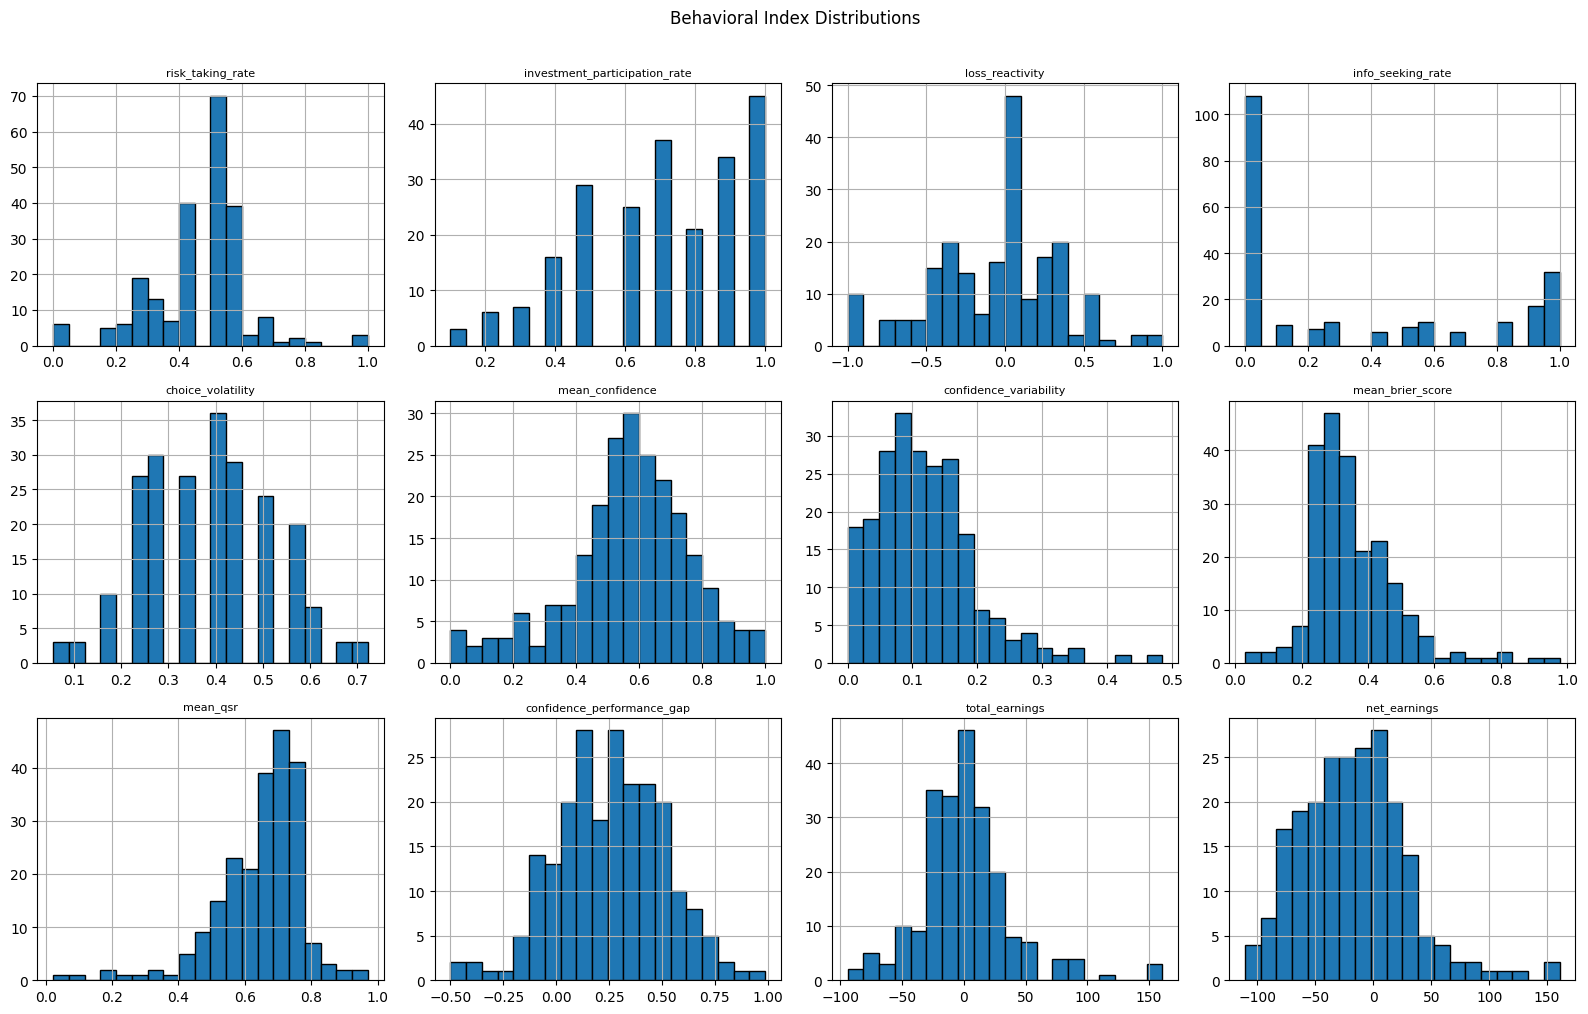

In [16]:
import os
import matplotlib.pyplot as plt

os.makedirs('../figures', exist_ok=True)

print('=== Behavioral Index Summary Statistics ===')
index_cols = [
    'risk_taking_rate', 'investment_participation_rate', 'loss_reactivity',
    'info_seeking_rate', 'choice_volatility', 'mean_confidence',
    'confidence_variability', 'mean_brier_score', 'mean_qsr',
    'confidence_performance_gap', 'total_earnings', 'net_earnings',
]
print(df_participant[index_cols].describe().round(3).T.to_string())

print('\n=== Extreme outliers (3×IQR threshold) ===')
outlier_pids = set()
for col in index_cols:
    s = df_participant[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    mask_out = (df_participant[col] < q1 - 3 * iqr) | (df_participant[col] > q3 + 3 * iqr)
    n_out = mask_out.sum()
    if n_out > 0:
        print(f'  {col}: {n_out} extreme outlier(s)')
        outlier_pids.update(df_participant[mask_out]['participant_id'].tolist())

print(f'\nParticipants with ≥1 extreme outlier on any index: {len(outlier_pids)}')
df_participant['any_outlier'] = df_participant['participant_id'].isin(outlier_pids).astype(int)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, index_cols):
    df_participant[col].dropna().hist(ax=ax, bins=20, edgecolor='black')
    ax.set_title(col, fontsize=8)
    ax.set_xlabel('')
for ax in axes.flat[len(index_cols):]:
    ax.set_visible(False)
plt.suptitle('Behavioral Index Distributions', y=1.01)
plt.tight_layout()
plt.savefig('../figures/index_distributions.png', dpi=150)
plt.show()

**Outlier summary:** Six participants (2.7%) show ≥1 extreme value on a behavioral index (3×IQR threshold). Affected indices: `total_earnings` (n = 3), `mean_brier_score` (n = 2), `mean_qsr` (n = 2), `confidence_variability` (n = 1). These participants are retained in all primary analyses; the `any_outlier` flag in `df_participant` enables sensitivity checks in Notebook 02.

Notable distributional features:
- **`loss_reactivity`**: missing for 16 participants (7.2%) who lacked consecutive invested rounds.
- **`mean_confidence`**: approximately normal (M = 0.57, SD = 0.20).
- **`investment_participation_rate`**: left-skewed (M = 0.71); most participants invested in most rounds.
- **`total_earnings`**: approximately symmetric around near-zero (M = 1.15, SD = 37.25), consistent with expected-value-neutral stimuli.
- **`net_earnings`**: left-shifted (M = −17.91); information costs erode gross returns.

## Step 6: Save Processed Outputs

In [17]:
os.makedirs('../data/processed', exist_ok=True)

eligible_df.to_csv('../data/processed/eligible_participants.csv', index=False)
df_round.to_csv('../data/processed/df_round.csv', index=False)
df_task_lagged.to_csv('../data/processed/df_task_lagged.csv', index=False)
df_participant.to_csv('../data/processed/df_participant.csv', index=False)

print('Saved all processed datasets.')
print(f'  eligible_participants: {len(eligible_df)} rows')
print(f'  df_round: {len(df_round)} rows')
print(f'  df_task_lagged: {len(df_task_lagged)} rows')
print(f'  df_participant: {len(df_participant)} rows')

Saved all processed datasets.
  eligible_participants: 223 rows
  df_round: 2230 rows
  df_task_lagged: 2007 rows
  df_participant: 223 rows


## Step 7: Descriptive Summary

In [18]:
print('=== Eligible participants by condition ===')
print(df_participant.groupby(['info_type', 'show_pl']).size().unstack())

print('\n=== Investment participation rate by condition ===')
print(df_participant.groupby(['info_type', 'show_pl'])['investment_participation_rate'].describe().round(3))

print('\n=== Info purchase rate by condition ===')
print(df_participant.groupby(['info_type', 'show_pl'])['info_seeking_rate'].describe().round(3))

print('\n=== Mean earnings by condition (gross investment return) ===')
print(df_participant.groupby(['info_type', 'show_pl'])['total_earnings'].describe().round(2))

print('\n=== Mean net earnings by condition (gross return minus info costs) ===')
print(df_participant.groupby(['info_type', 'show_pl'])['net_earnings'].describe().round(2))

print('\n=== Missing indices ===')
print(df_participant[['loss_reactivity', 'mean_brier_score', 'mean_qsr']].isna().sum())

print('\n=== EP-specified variables: presence check ===')
print('decision_time in df_round:', 'decision_time' in df_round.columns)
print('risk_rating in df_round:', 'risk_rating' in df_round.columns)
if 'risk_rating' in df_round.columns:
    print('risk_rating descriptive (overall):', df_round['risk_rating'].describe().round(2).to_dict())
if 'decision_time' in df_round.columns:
    print('Mean decision time by condition (seconds):')
    print(df_round.groupby(['info_type', 'show_pl'])['decision_time'].mean().round(2).unstack())

# Post-task self-reports check
participants_full = pd.read_csv('../data/participants.csv')
post_task_candidates = [c for c in participants_full.columns
                        if any(k in c.lower() for k in ['post', 'risk_attitude', 'overall_conf'])]
if post_task_candidates:
    print('\nPost-task self-report columns found:', post_task_candidates)
else:
    print('\nPost-task self-report columns: NONE FOUND — disclose as data gap in thesis Methods section.')

# Manipulation check analysis
manip_candidates = [c for c in participants_full.columns
                    if any(k in c.lower() for k in ['manip', 'understood', 'condition_check',
                                                      'check_info', 'check_feedback', 'check_condition'])]
if manip_candidates:
    print('\nManipulation check columns found:', manip_candidates)
    for col in manip_candidates:
        mc_df = eligible_df.merge(participants_full[['participant_id', col]], on='participant_id', how='left')
        print(f'\nManipulation check pass rate by condition ({col}):')
        print(mc_df.groupby(['info_type', 'show_pl'])[col].mean().round(3).unstack())
        ct_mc = pd.crosstab(mc_df['experiment_key'], mc_df[col].fillna(False))
        if ct_mc.shape == (6, 2):
            chi2_mc, p_mc, _, _ = chi2_contingency(ct_mc)
            print(f'Chi-square (condition × pass): χ²={chi2_mc:.3f}, p={p_mc:.3f}')
            if p_mc < 0.10:
                print('WARNING: Manipulation check pass rate is non-uniform across conditions.')
                print('Interpret H1–H4 between-condition comparisons cautiously and note this')
                print('differential as a potential confound in the thesis Results section.')
else:
    print('\nManipulation check columns: NONE FOUND')
    print('NOTE: No manipulation check data is available in the current dataset.')
    print('Disclose in thesis Methods: causal interpretation of H1–H4 is weakened because')
    print('condition understanding cannot be confirmed from available data.')

=== Eligible participants by condition ===
show_pl       False  True 
info_type                 
dynamic_cost     39     37
fixed_cost       39     35
none             35     38

=== Investment participation rate by condition ===
                      count   mean    std  min   25%   50%   75%  max
info_type    show_pl                                                 
dynamic_cost False     39.0  0.682  0.235  0.2  0.50  0.70  0.90  1.0
             True      37.0  0.708  0.252  0.1  0.60  0.70  0.90  1.0
fixed_cost   False     39.0  0.641  0.230  0.2  0.40  0.70  0.85  1.0
             True      35.0  0.726  0.244  0.1  0.55  0.80  0.90  1.0
none         False     35.0  0.709  0.202  0.3  0.50  0.70  0.90  1.0
             True      38.0  0.784  0.227  0.2  0.70  0.85  1.00  1.0

=== Info purchase rate by condition ===
                      count   mean    std  min   25%  50%  75%  max
info_type    show_pl                                               
dynamic_cost False     39.0  0.62

### Descriptive Patterns (Pre-Analysis)

*The following observations are descriptive only and should not be interpreted as confirmatory tests of H1–H5.*

**Investment participation:** Mean rates range from 64% (fixed-cost, delayed feedback) to 78% (no-info, immediate feedback). Immediate profit/loss feedback (show\_pl = True) is associated with slightly higher participation across all info conditions.

**Information purchase:** 0% in no-info conditions by design. Among info-available conditions, purchase rates are higher under delayed feedback (fixed-cost: 59%, dynamic-cost: 62%) than immediate feedback (43% and 40%), suggesting absence of round-by-round feedback increases demand for purchased information.

**Gross earnings:** Near zero across all conditions (range: −11 to +13), consistent with expected-value-neutral stimuli.

**Net earnings:** Negative in all information-available conditions (dynamic-cost delayed: M = −48; fixed-cost delayed: M = −34; immediate-feedback conditions: M ≈ −18 to −24) and positive in no-information conditions (M ≈ +7 to +13). Information costs outweigh any return advantage from purchasing.

**Missing indices:** `loss_reactivity` missing for 16 participants (7.2%); report n = 207 valid in Notebook 02 analyses. Calibration indices complete for all 223 participants.

---

## APA-Style Results Summary — Notebook 1: Data Preparation

### Participants

A total of 230 participants who completed the experimental session were assessed for eligibility. Seven (3.0%) were excluded for failing both embedded attention check items, yielding a final analytic sample of *N* = 223. Differential attrition analysis confirmed that attention-check failures were not concentrated in any experimental condition, χ²(5) = 6.79, *p* = .237.

The retained sample comprised 113 men (50.7%), 109 women (48.9%), and 1 participant who preferred not to disclose (0.4%). The modal age group was 35–44 years (*n* = 66, 29.6%), followed by 25–34 years (*n* = 58, 26.0%), 45–54 years (*n* = 36, 16.1%), 55–64 years (*n* = 25, 11.2%), 65 or older (*n* = 21, 9.4%), and 18–24 years (*n* = 17, 7.6%). Educational attainment was varied: bachelor's degree (39.5%), some college (16.1%), high school diploma (13.9%), master's degree (13.5%), associate degree (13.5%), and doctoral degree (3.6%). The majority were employed (77.6%). Income was distributed across the full range, with the modal bracket being $40k–$59k (22.9%). Self-reported investment experience was distributed as: limited (23.8%), some (22.0%), moderate (19.3%), none (17.5%), and extensive (17.5%). Participant compliance flags indicated 7 participants (3.1%) held senior executive or major shareholder positions and 10 (4.5%) were employed by a brokerage or exchange; these flags are retained as covariates in sensitivity analyses.

### Randomization

Participants were assigned to one of six experimental conditions defined by a 3 (information type: dynamic cost, fixed cost, none) × 2 (feedback: show_pl = True, False) factorial design. Condition sizes were: dynamic_cost/no-feedback (*n* = 39), dynamic_cost/feedback (*n* = 37), fixed_cost/no-feedback (*n* = 39), fixed_cost/feedback (*n* = 35), none/no-feedback (*n* = 35), none/feedback (*n* = 38). Randomization balance was verified via chi-square tests of independence between condition assignment and six demographic variables; all tests were non-significant (all *p* > .12): age, χ²(25) = 19.61, *p* = .767; gender, χ²(10) = 5.44, *p* = .860; education, χ²(25) = 29.11, *p* = .259; income, χ²(30) = 22.54, *p* = .834; employment, χ²(15) = 17.80, *p* = .273; investment experience, χ²(20) = 27.44, *p* = .123.

### Data Structure

The analytic dataset comprised 2,230 round-level observations (223 participants × up to 10 rounds), 2,007 lagged round-level observations (used for behavioral sequence analyses), and 223 participant-level aggregate records. All four behavioral indices showed adequate variability: investment participation rate (*M* = 0.708, *SD* = 0.234), risk-taking rate (*M* = 0.458, *SD* = 0.156), information-seeking rate (*M* = 0.346, *SD* = 0.404), and mean confidence (*M* = 0.567, *SD* = 0.195). Loss reactivity was computable for 207 of 223 participants (*M* = −0.073, *SD* = 0.404). Mean Brier score (*M* = 0.355, *SD* = 0.132) confirmed that the average participant was poorly calibrated relative to a perfect-calibration score of 0.